2026-08-12 12:09:31,292	INFO worker.py:2015 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
(raylet) Stack (most recent call first):
(raylet)   File "C:\Users\gayat\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 627 in job_logging_config
(raylet)   File "C:\Users\gayat\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 2789 in disconnect
(raylet)   File "C:\Users\gayat\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 2114 in shutdown
(raylet)   File "C:\Users\gayat\AppData\Local\Programs\Python\Python311\Lib\site-packages\ray\_private\worker.py", line 1170 in wrapper


AutoGluon Results -> Accuracy: 0.9667 | ROC-AUC: 1.0000
Calculating AutoGluon Feature Importances...


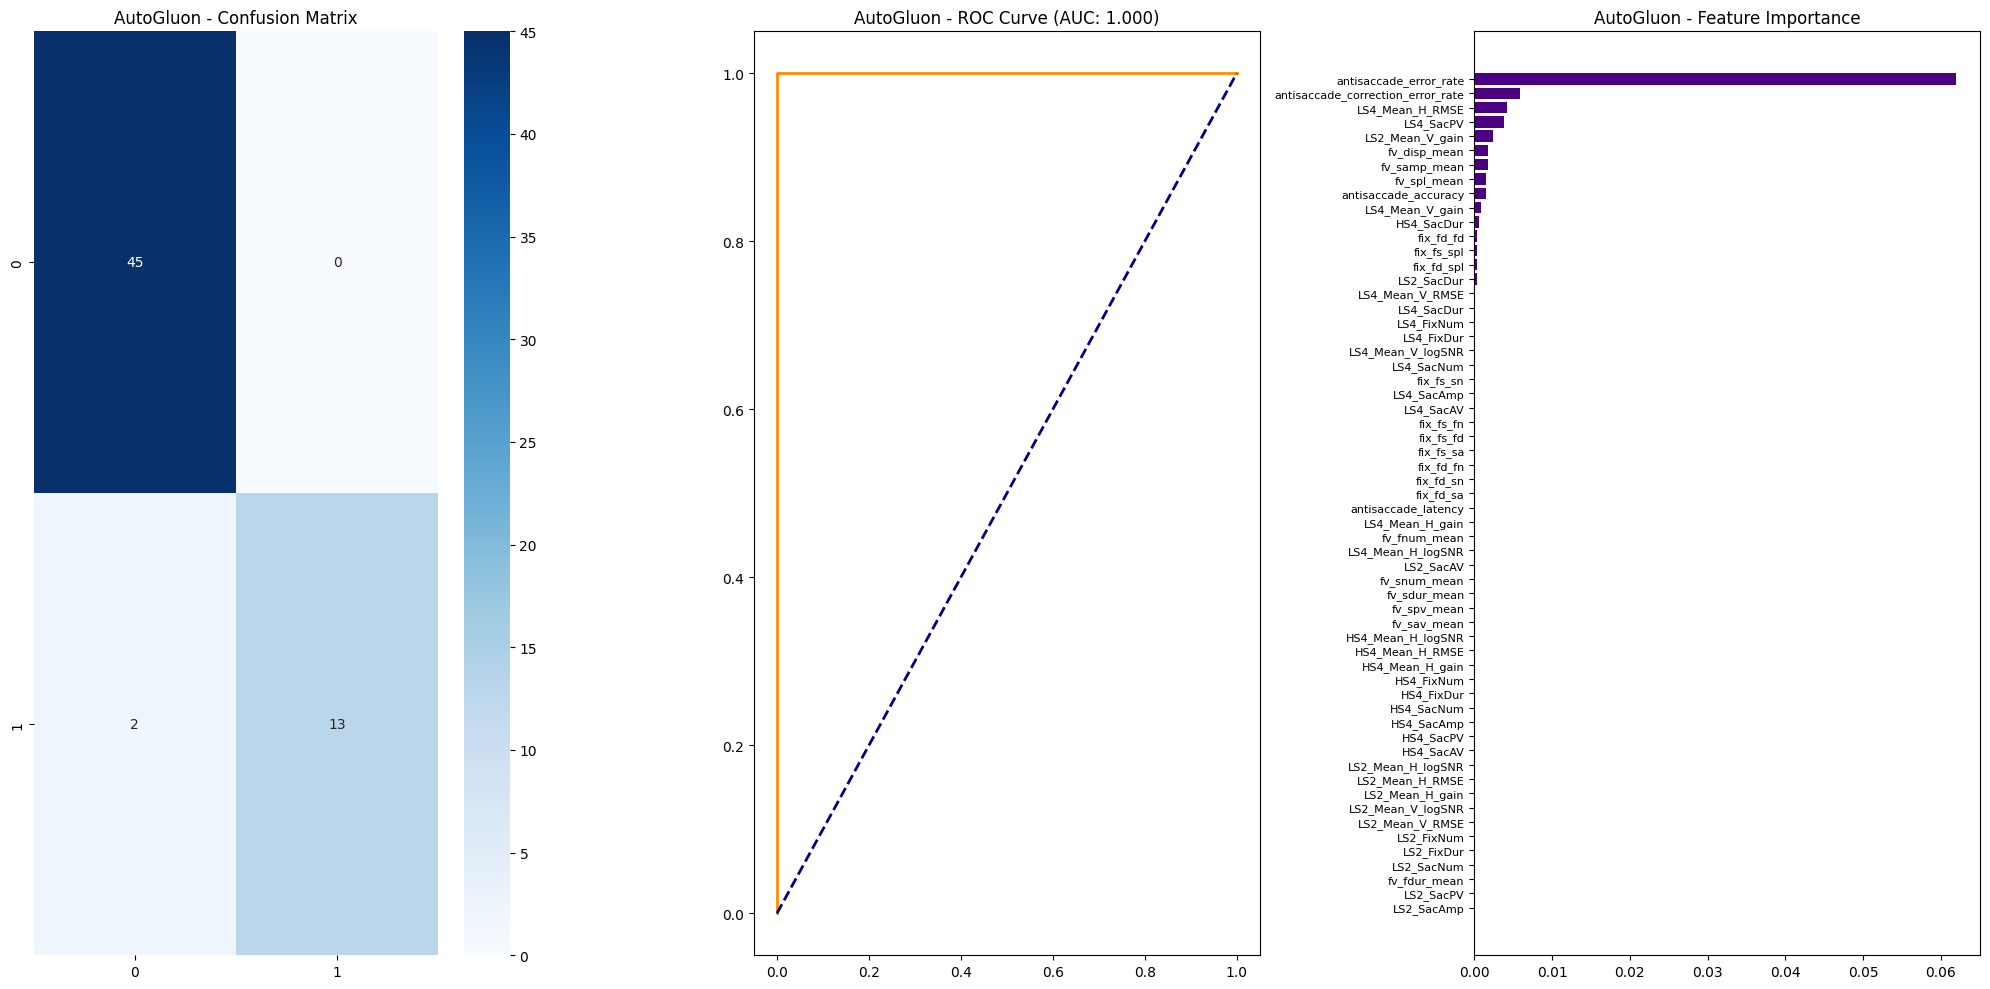

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, confusion_matrix
from autogluon.tabular import TabularPredictor

# 1. Load Data
df = pd.read_csv('synthetic_eye_tracking_HC_SZ_300.csv')
X = df.drop(columns=['subject_id', 'label', 'calibration_error'])
y = LabelEncoder().fit_transform(df['label'])

X_train, X_test, y_train, y_test, sub_train, sub_test, cal_train, cal_test = train_test_split(
    X, y, df['subject_id'], df['calibration_error'], test_size=0.2, stratify=y, random_state=42
)

# AutoGluon requires the target variable inside the DataFrame
ag_train = X_train.copy()
ag_train['target'] = y_train

ag_test = X_test.copy()
ag_test['target'] = y_test

# 2. Train Model
# fold_fitting_strategy added below to bypass Windows Ray crashes
predictor = TabularPredictor(label='target', eval_metric='roc_auc', path='autogluon_saved_model').fit(
    train_data=ag_train, 
    presets='best_quality',
    time_limit=180, 
    verbosity=0,
    ag_args_ensemble={'fold_fitting_strategy': 'sequential_local'} 
)

# 3. Predict & Save Results
y_pred = predictor.predict(ag_test).values
y_prob = predictor.predict_proba(ag_test).iloc[:, 1].values

pd.DataFrame({
    'subject_id': sub_test.values, 'actual_label': y_test, 
    'predicted_label': y_pred, 'predicted_prob': y_prob, 'calibration_error': cal_test.values
}).to_csv('predictions_autogluon.csv', index=False)

print(f"AutoGluon Results -> Accuracy: {accuracy_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# 4. Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("AutoGluon - Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2)
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title(f"AutoGluon - ROC Curve (AUC: {roc_auc_score(y_test, y_prob):.3f})")

# AutoGluon Feature Importance (calculated via permutation on the test set)
print("Calculating AutoGluon Feature Importances...")
fi_df = predictor.feature_importance(ag_test)

# AutoGluon returns a dataframe sorted by importance
importances = fi_df['importance'].values
fi_names = fi_df.index.tolist()

# Reverse arrays so the most important feature is at the top of the horizontal bar chart
importances_rev = importances[::-1]
fi_names_rev = fi_names[::-1]

axes[2].barh(range(len(importances_rev)), importances_rev, color='indigo')
axes[2].set_yticks(range(len(importances_rev)))
axes[2].set_yticklabels(fi_names_rev, fontsize=8)
axes[2].set_title("AutoGluon - Feature Importance")

plt.tight_layout()
plt.show()